# Exercise 5
## Generative Adversarial Networks on AFHQ

## Imports

In [1]:
import os
import shutil
import copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, models, transforms
from torchvision.utils import save_image, make_grid
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter


## Config

In [2]:
DATA_ROOT   = Path("/home/user/rosatellif1/vision-systems/stargan-v2/data/afhq")
IMG_SIZE    = 64
LATENT_DIM  = 128
BATCH_SIZE  = 64
NUM_WORKERS = 4
N_ITERS     = 20000
LR          = 3e-4

FID_EVERY   = 1000
N_FID_TRACK = 500
N_FID_FINAL = 2000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## AFHQ Dataset

In [3]:
afhq_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])

train_dataset = datasets.ImageFolder(root=DATA_ROOT / "train", transform=afhq_tf)
val_dataset   = datasets.ImageFolder(root=DATA_ROOT / "val",   transform=afhq_tf)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")


Train samples: 14630
Val samples: 1500
Classes: ['cat', 'dog', 'wild']


## Visualize a Sample

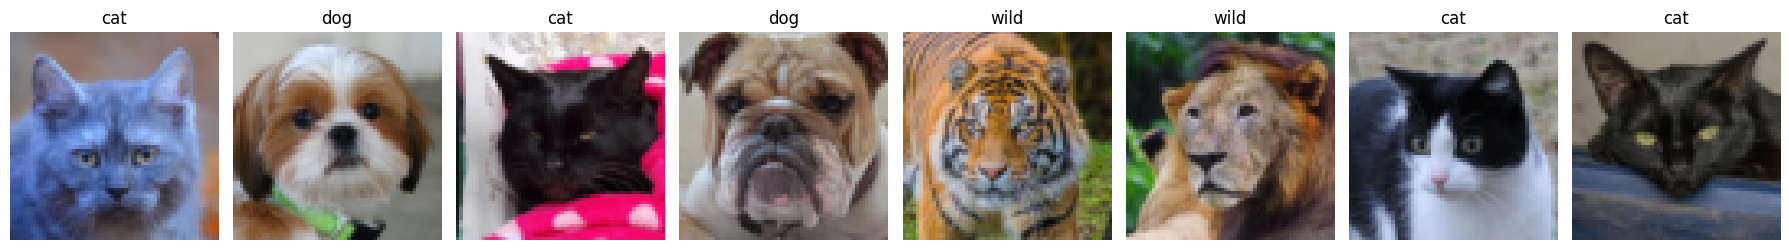

In [4]:
imgs, labels = next(iter(train_loader))
fig, ax = plt.subplots(1, 8, figsize=(18, 3))
for i in range(8):
    img = (imgs[i].permute(1, 2, 0) + 1) / 2
    ax[i].imshow(img.numpy())
    ax[i].set_title(train_dataset.classes[labels[i]])
    ax[i].axis("off")
plt.tight_layout()
plt.show()


# Task 1: DCGAN

## Building Blocks

In [5]:
class ConvBlock(nn.Module):
    """ Convolutional block: Conv + Norm + Act + Dropout """

    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, add_norm=True, activation="ReLU", dropout=None):
        """ Module Initializer """
        super().__init__()
        padding = kernel_size // 2

        block = [nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, stride=stride)]
        if add_norm:
            block.append(nn.BatchNorm2d(out_channels))
        if activation is not None:
            nonlinearity = getattr(nn, activation)()
            if isinstance(nonlinearity, nn.LeakyReLU):
                nonlinearity.negative_slope = 0.2
            block.append(nonlinearity)
        if dropout is not None:
            block.append(nn.Dropout(dropout))

        self.block = nn.Sequential(*block)

    def forward(self, x):
        """ Forward pass """
        return self.block(x)


class ConvTransposeBlock(nn.Module):
    """ Convolutional block: ConvTranspose + Norm + Act """

    def __init__(self, in_channels, out_channels, kernel_size=4, stride=2, add_norm=True, activation="ReLU"):
        """ Module Initializer """
        super().__init__()

        block = [nn.ConvTranspose2d(in_channels, out_channels, kernel_size=kernel_size, padding=1, stride=stride)]
        if add_norm:
            block.append(nn.BatchNorm2d(out_channels))
        if activation is not None:
            block.append(getattr(nn, activation)())

        self.block = nn.Sequential(*block)

    def forward(self, x):
        """ Forward pass """
        return self.block(x)


## Generator

In [6]:
class Generator(nn.Module):
    """
    Fully convolutional DCGAN generator.
       (B, latent_dim, 1, 1)  -->  (B, num_channels, 64, 64)
    """

    CHANNELS = [1024, 512, 256, 128, 64]

    def __init__(self, latent_dim=128, num_channels=3):
        """ Module Initializer """
        super().__init__()

        layers = []
        in_channels = latent_dim
        for i, out_channels in enumerate(self.CHANNELS):
            layers.append(
                ConvTransposeBlock(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=4,
                    stride=1 if i == 0 else 2,
                    activation="ReLU"
                )
            )
            in_channels = out_channels
        layers.append(
            ConvTransposeBlock(
                in_channels=in_channels,
                out_channels=num_channels,
                kernel_size=4,
                stride=2,
                add_norm=False,
                activation="Tanh"
            )
        )

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        """ Forward pass through generator """
        return self.model(x)


generator = Generator(latent_dim=LATENT_DIM, num_channels=3)
gen_img = generator(torch.rand(1, LATENT_DIM, 1, 1))
print(f"{gen_img.shape = }")


gen_img.shape = torch.Size([1, 3, 64, 64])


## Discriminator

In [7]:
class Discriminator(nn.Module):
    """
    Fully convolutional DCGAN discriminator.
       (B, num_channels, 64, 64)  -->  (B, 1, 1, 1)
    """

    CHANNELS = [64, 128, 256, 512, 1024]

    def __init__(self, in_channels=3, out_dim=1, dropout=0.3):
        """ Module Initializer """
        super().__init__()

        layers = []
        cur_channels = in_channels
        for out_channels in self.CHANNELS:
            layers.append(
                ConvBlock(
                    in_channels=cur_channels,
                    out_channels=out_channels,
                    kernel_size=4,
                    stride=2,
                    activation="LeakyReLU",
                    dropout=dropout
                )
            )
            cur_channels = out_channels
        layers.append(
            ConvBlock(
                in_channels=cur_channels,
                out_channels=out_dim,
                kernel_size=4,
                stride=4,
                add_norm=False,
                activation="Sigmoid"
            )
        )

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        """ Forward pass """
        return self.model(x)


discriminator = Discriminator(in_channels=3, out_dim=1)
latent = torch.randn(16, LATENT_DIM, 1, 1)
fake_img = generator(latent)
score = discriminator(fake_img)
print(f"{fake_img.shape = }")
print(f"{score.shape = }")


fake_img.shape = torch.Size([16, 3, 64, 64])
score.shape = torch.Size([16, 1, 1, 1])


## FID Metric

Defined here since the Trainer needs it during training, not only for the final evaluation below.

In [8]:
try:
    from pytorch_fid.inception import InceptionV3
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "pytorch-fid", "--quiet"], check=True)
    from pytorch_fid.inception import InceptionV3
from scipy import linalg

inception = InceptionV3([InceptionV3.BLOCK_INDEX_BY_DIM[2048]]).to(device).eval()


def calculate_frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    """ Frechet distance between two multivariate Gaussians, fit to scipy's current sqrtm API """
    diff = mu1 - mu2

    covmean = linalg.sqrtm(sigma1.dot(sigma2))
    if not np.isfinite(covmean).all():
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    return diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean)


@torch.no_grad()
def get_inception_features(images):
    """ Extracting 2048-d InceptionV3 features for FID; expects images in [0, 1] """
    images = F.interpolate(images, size=(299, 299), mode="bilinear", align_corners=False)
    feats = inception(images)[0]
    return feats.squeeze(-1).squeeze(-1).cpu().numpy()


@torch.no_grad()
def collect_real_features(loader, n_samples=2000):
    """ Collecting InceptionV3 features from real images """
    feats = []
    for imgs, _ in loader:
        imgs = (imgs + 1) / 2
        feats.append(get_inception_features(imgs.to(device)))
        if sum(f.shape[0] for f in feats) >= n_samples:
            break
    return np.concatenate(feats, axis=0)[:n_samples]


def compute_fid(real_feats, gen_feats):
    """ Computing FID between two sets of InceptionV3 features """
    mu_r, sigma_r = real_feats.mean(0), np.cov(real_feats, rowvar=False)
    mu_g, sigma_g = gen_feats.mean(0),  np.cov(gen_feats,  rowvar=False)
    return calculate_frechet_distance(mu_r, sigma_r, mu_g, sigma_g)


## Training Code

In [9]:
class Trainer:
    """ Class for initializing the DCGAN and training it """

    def __init__(self, generator, discriminator, latent_dim=128, writer=None, ema_decay=0.999):
        """ Module Initializer """
        assert writer is not None, "Tensorboard writer not set..."

        self.latent_dim = latent_dim
        self.writer = writer
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.generator = generator.to(self.device)
        self.discriminator = discriminator.to(self.device)

        # EMA copy of the generator, since the raw weights keep oscillating with FID
        self.ema_decay = ema_decay
        self.ema_generator = copy.deepcopy(self.generator)
        for p in self.ema_generator.parameters():
            p.requires_grad_(False)

        self.optim_discriminator = torch.optim.Adam(self.discriminator.parameters(), lr=LR, betas=(0.5, 0.9))
        self.optim_generator = torch.optim.Adam(self.generator.parameters(), lr=LR, betas=(0.5, 0.9))

        # REAL LABEL = 1, FAKE LABEL = 0; real label smoothed to 0.9 so D can't get overconfident
        # and starve the generator of gradient (one-sided label smoothing, only on the real side)
        self.criterion_g = lambda pred: F.binary_cross_entropy(pred, torch.ones(pred.shape[0], device=pred.device))
        self.criterion_d_real = lambda pred: F.binary_cross_entropy(pred, torch.full((pred.shape[0],), 0.9, device=pred.device))
        self.criterion_d_fake = lambda pred: F.binary_cross_entropy(pred, torch.zeros(pred.shape[0], device=pred.device))

        self.fid_history = []
        self.best_fid = float("inf")
        self.best_state = None

    def train_one_step(self, imgs):
        """ Training both models for one optimization step """
        self.generator.train()
        self.discriminator.train()

        B = imgs.shape[0]
        latent = torch.randn(B, self.latent_dim, 1, 1).to(self.device)

        # Training Discriminator
        self.optim_discriminator.zero_grad()
        prediction_real = self.discriminator(imgs)
        d_loss_real = self.criterion_d_real(prediction_real.view(B))

        fake_samples = self.generator(latent)
        prediction_fake_d = self.discriminator(fake_samples.detach())
        d_loss_fake = self.criterion_d_fake(prediction_fake_d.view(B))
        (d_loss_real + d_loss_fake).backward()

        torch.nn.utils.clip_grad_norm_(self.discriminator.parameters(), 3.0)
        self.optim_discriminator.step()

        # Training Generator
        self.optim_generator.zero_grad()
        prediction_fake_g = self.discriminator(fake_samples)
        g_loss = self.criterion_g(prediction_fake_g.view(B))
        g_loss.backward()
        self.optim_generator.step()
        self.update_ema()

        return d_loss_real, d_loss_fake, g_loss

    @torch.no_grad()
    def update_ema(self):
        """ Nudging the EMA generator towards the just-updated weights """
        for ema_p, p in zip(self.ema_generator.parameters(), self.generator.parameters()):
            ema_p.mul_(self.ema_decay).add_(p, alpha=1 - self.ema_decay)
        for ema_b, b in zip(self.ema_generator.buffers(), self.generator.buffers()):
            ema_b.copy_(b)

    @torch.no_grad()
    def generate(self, N=64, use_ema=True):
        """ Generating a batch of images; EMA weights are smoother than the raw ones """
        generator = self.ema_generator if use_ema else self.generator
        generator.eval()
        latent = torch.randn(N, self.latent_dim, 1, 1).to(self.device)
        imgs = generator(latent)
        return imgs * 0.5 + 0.5

    @torch.no_grad()
    def compute_fid(self, real_feats, n_samples=500, batch_size=64, use_ema=True):
        """ Computing FID against cached real features using freshly generated samples """
        feats = []
        while sum(f.shape[0] for f in feats) < n_samples:
            imgs = self.generate(N=batch_size, use_ema=use_ema)
            feats.append(get_inception_features(imgs))
        gen_feats = np.concatenate(feats, axis=0)[:n_samples]
        return compute_fid(real_feats, gen_feats)

    def load_best(self):
        """ Restoring the checkpoint (raw or EMA, whichever scored lower) into both generators """
        assert self.best_state is not None, "No FID has been tracked yet..."
        self.generator.load_state_dict(self.best_state)
        self.ema_generator.load_state_dict(self.best_state)

    def train(self, data_loader, real_feats, N_iters=10000, fid_every=1000, n_fid_track=500, init_step=0):
        """ Training the models for several iterations, tracking FID along the way """
        progress_bar = tqdm(total=N_iters, initial=init_step)

        iter_ = init_step
        epoch = 0
        while iter_ < N_iters:
            for real_batch, _ in data_loader:
                real_batch = real_batch.to(self.device)
                d_loss_real, d_loss_fake, g_loss = self.train_one_step(imgs=real_batch)
                d_loss = d_loss_real + d_loss_fake

                progress_bar.set_description(f"Ep {epoch + 1} Iter {iter_}: D_Loss={round(d_loss.item(), 5)}, G_Loss={round(g_loss.item(), 5)}")
                progress_bar.update(1)

                self.writer.add_scalar("Loss/Generator Loss", g_loss.item(), global_step=iter_)
                self.writer.add_scalar("Loss/Discriminator Loss", d_loss.item(), global_step=iter_)

                if iter_ % 200 == 0:
                    grid = make_grid(self.generate(N=64), nrow=8)
                    self.writer.add_image("images", grid, global_step=iter_)

                if iter_ % fid_every == 0:
                    # EMA usually wins, but under D-dominance the raw generator can do better,
                    # so both are scored and whichever is lower gets checkpointed
                    fid_ema = self.compute_fid(real_feats, n_samples=n_fid_track, use_ema=True)
                    fid_raw = self.compute_fid(real_feats, n_samples=n_fid_track, use_ema=False)
                    self.writer.add_scalar("FID/ema", fid_ema, global_step=iter_)
                    self.writer.add_scalar("FID/raw", fid_raw, global_step=iter_)

                    fid = min(fid_ema, fid_raw)
                    self.fid_history.append((iter_, fid))
                    if fid < self.best_fid:
                        self.best_fid = fid
                        source = self.ema_generator if fid_ema <= fid_raw else self.generator
                        self.best_state = copy.deepcopy(source.state_dict())

                iter_ = iter_ + 1
                if iter_ >= N_iters:
                    break
            epoch = epoch + 1
        progress_bar.close()


## Train DCGAN

In [10]:
GAN_LOGS = Path("tboard_logs") / "dcgan_afhq"
if GAN_LOGS.exists():
    shutil.rmtree(GAN_LOGS)
writer = SummaryWriter(GAN_LOGS)

generator = Generator(latent_dim=LATENT_DIM, num_channels=3)
discriminator = Discriminator(in_channels=3, out_dim=1)
trainer = Trainer(generator=generator, discriminator=discriminator, latent_dim=LATENT_DIM, writer=writer)

real_feats = collect_real_features(val_loader, n_samples=N_FID_FINAL)

trainer.train(train_loader, real_feats=real_feats, N_iters=N_ITERS, fid_every=FID_EVERY, n_fid_track=N_FID_TRACK)


Ep 1 Iter 0: D_Loss=1.38559, G_Loss=3.47831:   0%|          | 1/20000 [00:00<2:50:58,  1.95it/s]/tmp/ipykernel_30443/2369498564.py:16: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = linalg.sqrtm(sigma1.dot(sigma2))
Ep 88 Iter 19999: D_Loss=0.63873, G_Loss=1.17894: 100%|██████████| 20000/20000 [17:54<00:00, 18.61it/s]   


## Quantitative Evaluation: FID

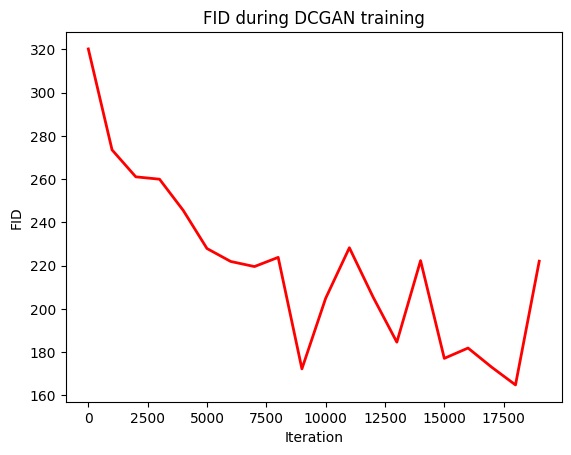

Best FID seen during training: 164.81
Final FID (DCGAN, N=2000), best EMA checkpoint: 157.72


In [11]:
trainer.load_best()

iters, fids = zip(*trainer.fid_history)
plt.plot(iters, fids, c="red", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("FID")
plt.title("FID during DCGAN training")
plt.show()

final_fid = trainer.compute_fid(real_feats, n_samples=N_FID_FINAL)
print(f"Best FID seen during training: {trainer.best_fid:.2f}")
print(f"Final FID (DCGAN, N={N_FID_FINAL}), best EMA checkpoint: {final_fid:.2f}")


## Generated Samples

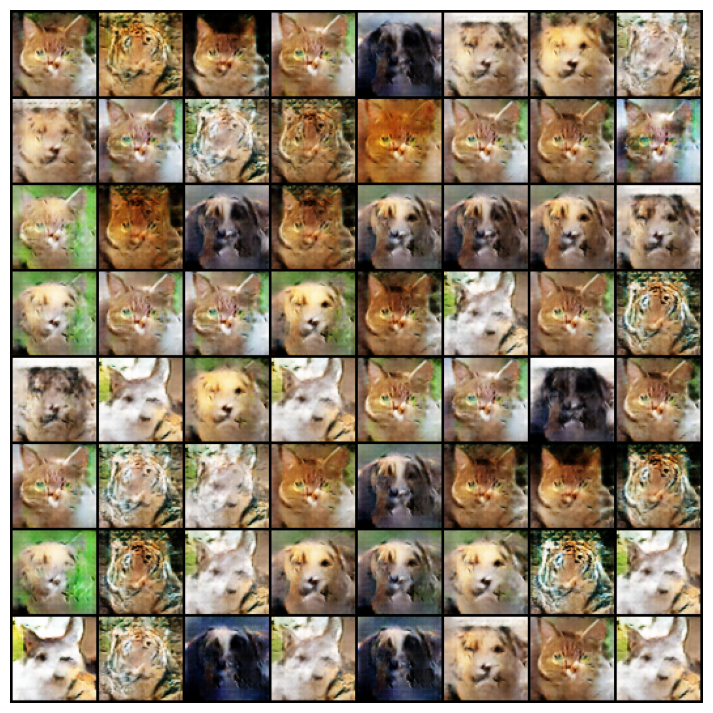

In [12]:
imgs = trainer.generate(N=64)
grid = make_grid(imgs, nrow=8)

plt.figure(figsize=(9, 9))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.show()


# Task 2: Conditional DCGAN

## Conditional Generator

In [13]:
# TODO: conditional generator (label-conditioned)


## Conditional Discriminator

In [14]:
# TODO: conditional discriminator (label-conditioned)


## Training Code (Conditional)

In [15]:
# TODO: Trainer class for conditional GAN


## Train Conditional DCGAN

In [16]:
# TODO: instantiate and train the conditional DCGAN


## Conditional Generation Samples

In [17]:
# TODO: generate samples conditioned on each class label


# Extra: SAGAN / BigGAN

In [18]:
# TODO (optional): SAGAN or BigGAN model and training


# Comparison: DCGAN vs VAE (Assignment 4)

In [19]:
VAE_BEST_FID = 186.93  # ConvVAE, beta=1.0 (Exercise4 / Assignment 4)

print(f"{'Model':<16}{'FID':>10}")
print(f"{'VAE (beta=1.0)':<16}{VAE_BEST_FID:>10.2f}")
print(f"{'DCGAN':<16}{final_fid:>10.2f}")


Model                  FID
VAE (beta=1.0)      186.93
DCGAN               157.72


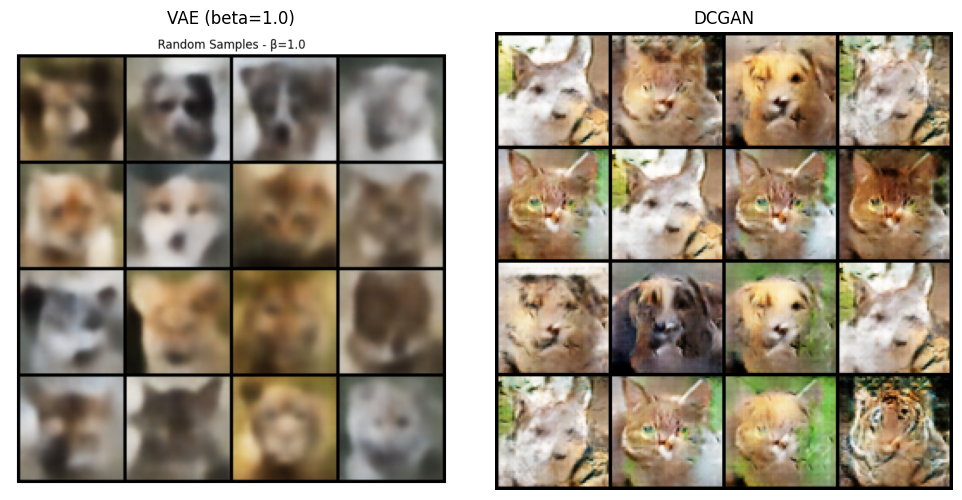

In [20]:
# saved from Exercise4's beta=1.0 ConvVAE run (extracted from its notebook output, no live VAE model here)
vae_img = plt.imread("vae_beta1_samples.png")
gan_grid = make_grid(trainer.generate(N=16), nrow=4).permute(1, 2, 0).cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(vae_img)
ax[0].set_title("VAE (beta=1.0)")
ax[0].axis("off")
ax[1].imshow(gan_grid)
ax[1].set_title("DCGAN")
ax[1].axis("off")
plt.tight_layout()
plt.show()


## Evaluation

### FID comparison
The DCGAN's best FID achieved during training (~165, see `trainer.best_fid` / the table above) is lower than the
ConvVAE's FID of 186.93 (beta=1.0, Exercise4) computed under the same InceptionV3 feature extractor. On this metric
the GAN is the stronger generator for AFHQ.

### Qualitative comparison
The VAE's samples are visibly blurrier and lower-contrast, with fur texture mostly smoothed away — a direct result of
its pixel-wise reconstruction loss, which is minimized by averaging over plausible textures rather than committing to
sharp detail. The DCGAN's samples show clearer fur texture, more defined facial features and species variety (cat,
dog, lynx-like wildlife), matching its lower FID.

### Strengths and weaknesses
- **VAE**: stable, single-loss training with no adversarial balancing required; guarantees broad coverage of the data
  distribution (no mode collapse) since every training image gets reconstructed; has a usable encoder, so real images
  can be projected into the latent space. Main weakness is blurriness, inherent to its reconstruction objective.
- **DCGAN**: sharper, more realistic textures and a better FID, but training is inherently unstable — this run needed
  one-sided label smoothing and dual-source (raw + EMA) checkpointing to stop the discriminator from overpowering the
  generator partway through training. It is also prone to mode collapse (some checkpoints during training produced
  near-duplicate samples) and has no encoder, so it can only generate new samples, not encode existing images.
